# Linear Regression
The linear regression neuron algorithm is a classic ML algorithm that uses gradient descent to train a weight and a bias as parameters of a line of best fit.

## Gradient Descent
The gradient descent algorithm finds a local minimum of the cost function: $$ C(x) = \frac{1}{2n} \sum_{i=1}^n (\hat{y_i} - y_i)^2 $$

We will look at the gradient descent algorithm with the cost function for the linear regression algorithm.

Where $\hat{y_i} = \sigma(z_i)$; $\sigma(z)$ is the activation function, which in this case is linear: $\sigma(z) = z$. Furthermore, $n$ is the number of training datapoints and $y_i$ is the true ith value of the training data.

Finally, in the linear regression algorithm with weight $w$ and bias $b$, we calculate $z$ as $z=w x_i + b$.

Then we can substitute this into the cost function: $$ C(x) = \frac{1}{2n} \sum_{i=1}^n (\hat{y_i} - y_i)^2 = \frac{1}{2n} \sum_{i=1}^n (w x_i + b - y_i)^2$$

Now, we calculate the partial derivative of the cost function with respect to $w$: $$\frac{\partial}{\partial w} C(x) = \frac{\partial}{\partial w} \frac{1}{2n} \sum_{i=1}^n (w x_i + b - y_i)^2 = \frac{1}{2n} \sum_{i=1}^n \frac{\partial}{\partial w} (w x_i + b - y_i)^2$$

Now, apply the chain rule: $$\frac{1}{2n} \sum_{i=1}^n \frac{\partial}{\partial w} (w x_i + b - y_i)^2 = \frac{1}{n} \sum_{i=1}^n(w x_i + b - y_i) x_i = \frac{1}{n} \sum_{i=1}^n(\hat{y_i} - y_i) x_i$$

Now, we calculate the partial derivate of the cost function with respect to $b$: $$\frac{\partial}{\partial b} C(x) = \frac{\partial}{\partial b} \frac{1}{2n} \sum_{i=1}^n (w x_i + b - y_i)^2 = \frac{1}{2n} \sum_{i=1}^n \frac{\partial}{\partial b} (w x_i + b - y_i)^2$$

Now, apply the chain rule: $$\frac{1}{2n} \sum_{i=1}^n \frac{\partial}{\partial b} (w x_i + b - y_i)^2 = \frac{1}{n} \sum_{i=1}^n(w x_i + b - y_i) = \frac{1}{n} \sum_{i=1}^n(\hat{y_i} - y_i)$$

Thus, we can minimize both of these partial derivatives to minimize the cost function. We do this by, at each step, calculating the partial derivatives and then updating the weight and bias, given the learning rate $\alpha$:
$$ w \leftarrow w - \alpha \frac{\partial C}{\partial w}$$
$$ b \leftarrow b - \alpha \frac{\partial C}{\partial b}$$

## Linear Regression Algorithm

The linear regression algorithm uses gradient descent as described above to minimize its cost function:
1. Calculate $\hat{y_i} = w x_i + b$
2. Calculate $\frac{\partial C}{\partial w}$ and $\frac{\partial C}{\partial b}$ as described above
3. Update weights and biases, as described above
4. Repeat until maximum number of epochs is reached

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

## Data Preprocessing
We will load in the AutoMPG data that we created in the preprocessing step:

In [3]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/AutoMPG-Dataset"
train_X = np.load(f"{data_dir}/train_X.npy")
train_y = np.load(f"{data_dir}/train_y.npy")
test_X = np.load(f"{data_dir}/test_X.npy")
test_y = np.load(f"{data_dir}/test_y.npy")
train_X

array([[ 1.49630792,  1.08923273,  0.66835485, ...,  0.77258661,
        -0.46138749, -0.49701778],
       [ 1.49630792,  1.50162428,  1.58460471, ...,  0.77258661,
        -0.46138749, -0.49701778],
       [ 1.49630792,  1.19472824,  1.1919262 , ...,  0.77258661,
        -0.46138749, -0.49701778],
       ...,
       [-0.85524411, -0.69460048,  0.27567634, ..., -1.29110112,
         2.16192996, -0.49701778],
       [ 0.3205319 , -0.29179943,  0.74689055, ..., -1.29110112,
         2.16192996, -0.49701778],
       [-0.85524411, -1.00149651, -0.87618062, ..., -1.29110112,
         2.16192996, -0.49701778]], shape=(279, 8))

We will compare horsepower with MPG and attempt to model this:

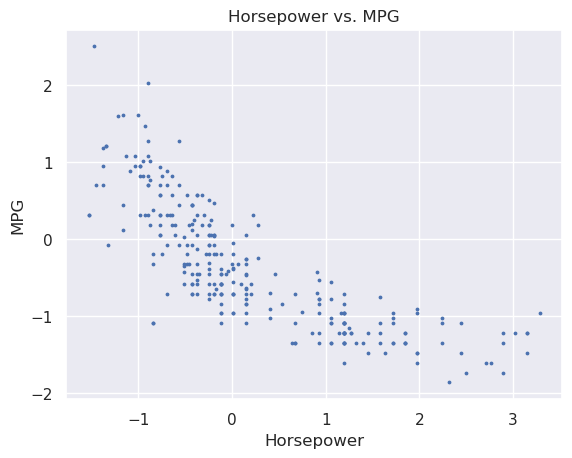

In [4]:
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs. MPG")
plt.scatter(train_X[:, 2], train_y[:], s = 3)
plt.show()

We can see that it follows a similar structure to the function $y = \frac{1}{x}$.

## Implementation

In [5]:
class LinearRegressionNeuron():
    def __init__(self):
        pass
        
    def train(self, X, y, eta = 0.0001, epochs=100):
        self.n = X.shape[0]
        self.weight = np.random.rand()
        self.bias = np.random.rand()
        errors = np.empty(epochs)
        for epoch in range(epochs):
            y_hats = np.empty(self.n)
            for i in range(self.n):
                y_hats[i] = self.predict(X[i])
            for i in range(self.n):
                self.weight += -eta * (y_hats[i] - y[i]) * X[i] / self.n
                self.bias += -eta * (y_hats[i] - y[i]) / self.n
            errors[epoch] = (self.cost(y, y_hats))
        return errors
    
    def cost(self, y, y_hat):
        cost = 0.0
        for i in range(len(y)):
            cost += (y_hat[i] - y[i])**2
        cost /= 2.0*len(y)
        return cost

    def predict(self, x):
        return self.weight * x + self.bias

## Data Analysis

First, we will compare various learning rates for the linear regression:

/tmp/ipykernel_57793/3745738650.py:23: RuntimeWarning: overflow encountered in scalar add
  cost += (y_hat[i] - y[i])**2
/tmp/ipykernel_57793/3745738650.py:23: RuntimeWarning: overflow encountered in scalar power
  cost += (y_hat[i] - y[i])**2
/tmp/ipykernel_57793/3745738650.py:15: RuntimeWarning: overflow encountered in scalar multiply
  self.weight += -eta * (y_hats[i] - y[i]) * X[i] / self.n
/tmp/ipykernel_57793/3745738650.py:16: RuntimeWarning: overflow encountered in scalar multiply
  self.bias += -eta * (y_hats[i] - y[i]) / self.n
/tmp/ipykernel_57793/3745738650.py:28: RuntimeWarning: invalid value encountered in scalar add
  return self.weight * x + self.bias
/tmp/ipykernel_57793/3745738650.py:15: RuntimeWarning: invalid value encountered in scalar add
  self.weight += -eta * (y_hats[i] - y[i]) * X[i] / self.n
/tmp/ipykernel_57793/3745738650.py:16: RuntimeWarning: invalid value encountered in scalar add
  self.bias += -eta * (y_hats[i] - y[i]) / self.n


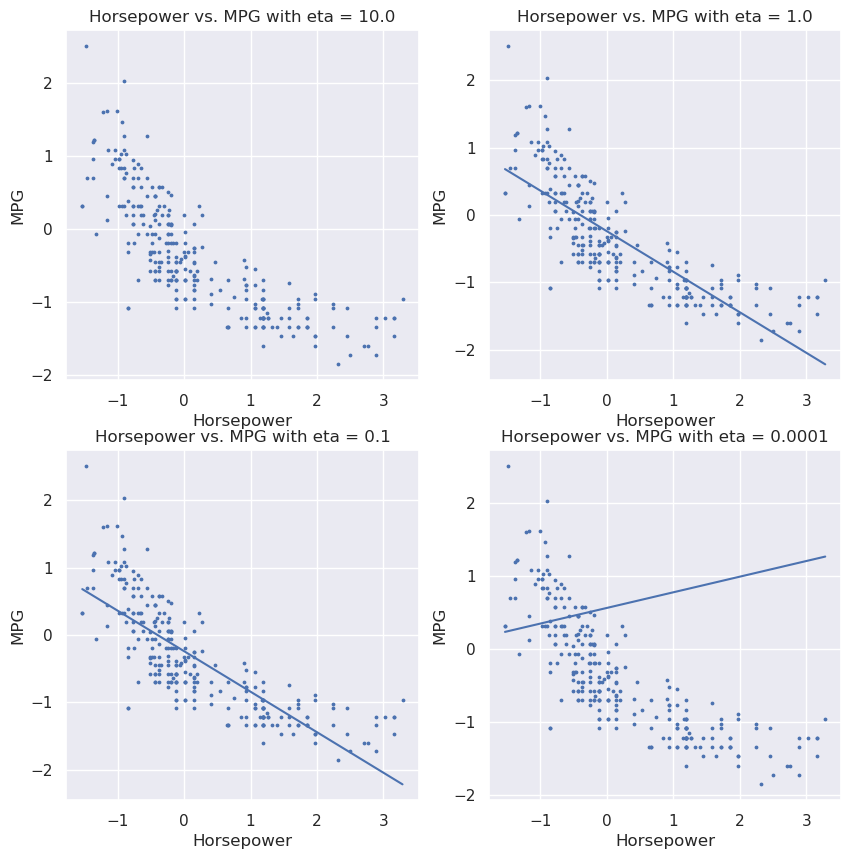

In [6]:
fig, axs = plt.subplots(2, 2, figsize = (10, 10))
t = np.linspace(min(train_X[:, 2]), max(train_X[:, 2]), 1000)

Neuron_1 = LinearRegressionNeuron()
neuron_1_eta = 10.0
errors_1 = Neuron_1.train(train_X[:, 2], train_y[:], eta = neuron_1_eta, epochs = 1000)
t_y_1 = [Neuron_1.predict(t_i) for t_i in t]
axs[0, 0].plot(t, t_y_1)
axs[0, 0].set_xlabel("Horsepower")
axs[0, 0].set_ylabel("MPG")
axs[0, 0].set_title(f"Horsepower vs. MPG with eta = {neuron_1_eta}")
axs[0, 0].scatter(train_X[:, 2], train_y[:], s = 3)

Neuron_2 = LinearRegressionNeuron()
neuron_2_eta = 1.0
errors_2 = Neuron_2.train(train_X[:, 2], train_y[:], eta = neuron_2_eta, epochs = 1000)
t_y_2 = [Neuron_2.predict(t_i) for t_i in t]
axs[0, 1].plot(t, t_y_2)
axs[0, 1].set_xlabel("Horsepower")
axs[0, 1].set_ylabel("MPG")
axs[0, 1].set_title(f"Horsepower vs. MPG with eta = {neuron_2_eta}")
axs[0, 1].scatter(train_X[:, 2], train_y[:], s = 3)

Neuron_3 = LinearRegressionNeuron()
neuron_3_eta = 0.1
errors_3 = Neuron_3.train(train_X[:, 2], train_y[:], eta = neuron_3_eta, epochs = 1000)
t_y_3 = [Neuron_3.predict(t_i) for t_i in t]
axs[1, 0].plot(t, t_y_3)
axs[1, 0].set_xlabel("Horsepower")
axs[1, 0].set_ylabel("MPG")
axs[1, 0].set_title(f"Horsepower vs. MPG with eta = {neuron_3_eta}")
axs[1, 0].scatter(train_X[:, 2], train_y[:], s = 3)

Neuron_4 = LinearRegressionNeuron()
neuron_4_eta = 0.0001
errors_4 = Neuron_4.train(train_X[:, 2], train_y[:], eta = neuron_4_eta, epochs = 1000)
t_y_4 = [Neuron_4.predict(t_i) for t_i in t]
axs[1, 1].plot(t, t_y_4)
axs[1, 1].set_xlabel("Horsepower")
axs[1, 1].set_ylabel("MPG")
axs[1, 1].set_title(f"Horsepower vs. MPG with eta = {neuron_4_eta}")
axs[1, 1].scatter(train_X[:, 2], train_y[:], s = 3)

Notice how, for the learning rate of 10.0, the gradient descent diverges. Meanwhile, the learning rate of 0.0001 is too small, so it is unable to fit the line to the datapoints. However, the learning rates of 1.0 and 0.1 were pretty good approximations.

Text(0.5, 1.0, 'Error with eta = 0.0001')

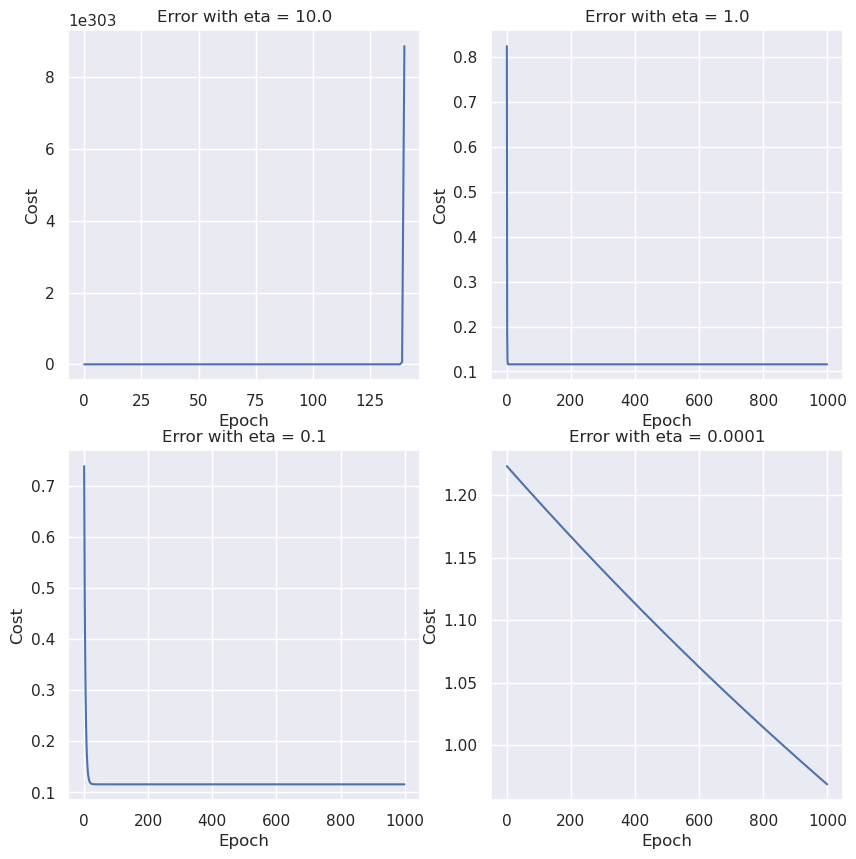

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))


ax[0, 0].plot(errors_1)
ax[0, 0].set_xlabel("Epoch")
ax[0, 0].set_ylabel("Cost")
ax[0, 0].set_title(f"Error with eta = {neuron_1_eta}")

ax[0, 1].plot(errors_2)
ax[0, 1].set_xlabel("Epoch")
ax[0, 1].set_ylabel("Cost")
ax[0, 1].set_title(f"Error with eta = {neuron_2_eta}")

ax[1, 0].plot(errors_3)
ax[1, 0].set_xlabel("Epoch")
ax[1, 0].set_ylabel("Cost")
ax[1, 0].set_title(f"Error with eta = {neuron_3_eta}")

ax[1, 1].plot(errors_4)
ax[1, 1].set_xlabel("Epoch")
ax[1, 1].set_ylabel("Cost")
ax[1, 1].set_title(f"Error with eta = {neuron_4_eta}")

Here, we can confirm that the learning rate of 10.0 diverges and the learning rate of 0.0001 is unable to converge. However, both the learning rates of 1.0 and 0.1 are able to converge quickly.

Minimum error across any learning rate:

In [8]:
min_linear_error = min(np.concatenate((errors_1, errors_2, errors_3, errors_4)))
print(f"Minimum error: {min_linear_error}")

Minimum error: 0.1159030957607154


# Polynomial Regression

## Algorithm

The polynomial regression algorithm works by fitting multiple weights to the data and treating those weights as coefficients to a higher-degree polynomial. This creates a polynomial of best fit to the training data.

Now, we calculate the partial derivative of the cost function with respect to $w_k$, where $w_k$ is the weight corresponding to the $k$ degree term in the polynomial: $$\frac{\partial}{\partial w_k} C(x) = \frac{k}{n} \sum_{i=1}^n(\hat{y_i} - y_i) x_i^{k-1}$$

This partial derivative is calculated in the exact same way as for linear regression. Furthermore, the bias term is the exact same. The only other difference is the weight update:
$$ w_k \leftarrow w_k - \alpha^k \frac{\partial C}{\partial w_k}$$

This is to prevent the high-order terms from dominating.

## Implementation

In [9]:
class PolynomialRegressionNeuron():
    def __init__(self, degree = 2):
        self.degree = degree
        
    def train(self, X, y, eta = 0.0001, epochs=100):
        self.n = X.shape[0]
        self.weights = np.random.rand(self.degree)
        self.bias = np.random.rand()
        errors = np.empty(epochs)
        for epoch in range(epochs):
            y_hats = np.empty(self.n)
            for i in range(self.n):
                y_hats[i] = self.predict(X[i])
            for i in range(self.n):
                for j in range(self.degree):
                    self.weights[j] += -eta**(j+1) * (y_hats[i] - y[i]) * X[i]**(j+1) / self.n
                self.bias += -eta * (y_hats[i] - y[i]) / self.n
            errors[epoch] = (self.cost(y, y_hats))
        return errors
    
    def cost(self, y, y_hat):
        cost = 0.0
        for i in range(len(y)):
            cost += (y_hat[i] - y[i])**2
        cost /= 2.0*len(y)
        return cost

    def predict(self, x):
        return sum(self.weights[i] * x**(i+1) for i in range(self.degree)) + self.bias

## Data Analysis

We will compare polynomials of degree 2-4 on their error and polynomials of best fit.

### Quadratic model

Minimum error: 0.0867356636425952


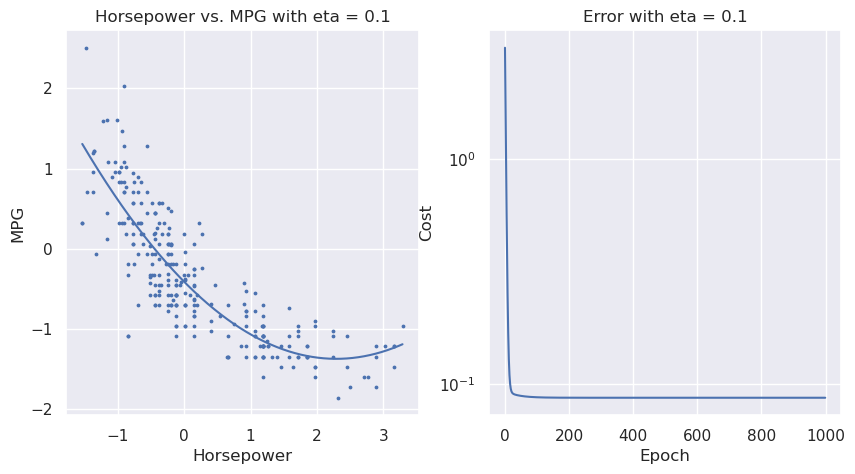

In [10]:
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
t = np.linspace(min(train_X[:, 2]), max(train_X[:, 2]), 1000)

Neuron = PolynomialRegressionNeuron(degree = 2)
neuron_eta = 0.1
errors = Neuron.train(train_X[:, 2], train_y[:], eta = neuron_eta, epochs = 1000)
t_y = [Neuron.predict(t_i) for t_i in t]
axs[0].plot(t, t_y)
axs[0].set_xlabel("Horsepower")
axs[0].set_ylabel("MPG")
axs[0].set_title(f"Horsepower vs. MPG with eta = {neuron_eta}")
axs[0].scatter(train_X[:, 2], train_y[:], s = 3)

axs[1].semilogy(errors)
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Cost")
axs[1].set_title(f"Error with eta = {neuron_eta}")

min_quad_error = min(errors)
print(f"Minimum error: {min_quad_error}")

### Cubic model

Minimum error: 0.08781005109176647


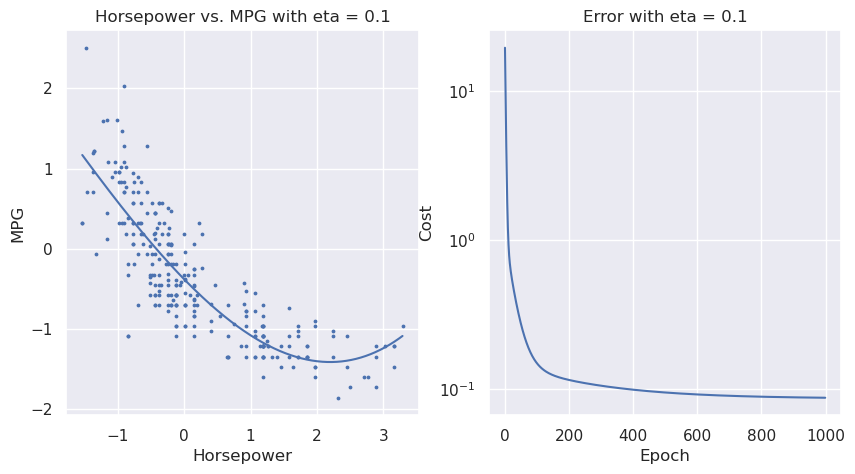

In [11]:
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
t = np.linspace(min(train_X[:, 2]), max(train_X[:, 2]), 1000)

Neuron = PolynomialRegressionNeuron(degree = 3)
neuron_eta = 0.1
errors = Neuron.train(train_X[:, 2], train_y[:], eta = neuron_eta, epochs = 1000)
t_y = [Neuron.predict(t_i) for t_i in t]
axs[0].plot(t, t_y)
axs[0].set_xlabel("Horsepower")
axs[0].set_ylabel("MPG")
axs[0].set_title(f"Horsepower vs. MPG with eta = {neuron_eta}")
axs[0].scatter(train_X[:, 2], train_y[:], s = 3)

axs[1].semilogy(errors)
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Cost")
axs[1].set_title(f"Error with eta = {neuron_eta}")

min_cubic_error = min(errors)
print(f"Minimum error: {min_cubic_error}")

### Quartic model

Minimum error: 0.14907054313508455


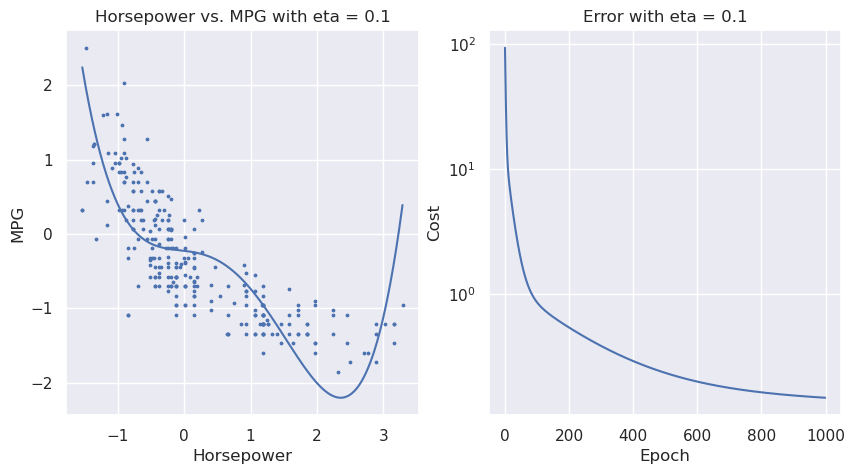

In [12]:
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
t = np.linspace(min(train_X[:, 2]), max(train_X[:, 2]), 1000)

Neuron = PolynomialRegressionNeuron(degree = 4)
neuron_eta = 0.1
errors = Neuron.train(train_X[:, 2], train_y[:], eta = neuron_eta, epochs = 1000)
t_y = [Neuron.predict(t_i) for t_i in t]
axs[0].plot(t, t_y)
axs[0].set_xlabel("Horsepower")
axs[0].set_ylabel("MPG")
axs[0].set_title(f"Horsepower vs. MPG with eta = {neuron_eta}")
axs[0].scatter(train_X[:, 2], train_y[:], s = 3)

axs[1].semilogy(errors)
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Cost")
axs[1].set_title(f"Error with eta = {neuron_eta}")

min_quartic_error = min(errors)
print(f"Minimum error: {min_quartic_error}")

# Error Analysis

Finally, we can compare the errors across the various regressions:

In [13]:
print("Minimum linear error: ", min_linear_error)
print("Minimum quadratic error: ", min_quad_error)
print("Minimum cubic error: ", min_cubic_error)
print("Minimum quartic error: ", min_quartic_error)

Minimum linear error:  0.1159030957607154
Minimum quadratic error:  0.0867356636425952
Minimum cubic error:  0.08781005109176647
Minimum quartic error:  0.14907054313508455


As we can see, the polynomials each model the training data much better than the line of best fit. However, the error reductions drop off after the quadratic regression, so we can conclude that the data is best modeled by a quadratic regression.

Now, we will compare the models against the testing data:

In [14]:
linear_neuron = LinearRegressionNeuron()
linear_errors = linear_neuron.train(train_X[:, 2], train_y[:], eta = 0.1, epochs = 1000)
linear_predictions = linear_neuron.predict(test_X[:, 2])
print(f"Linear neuron testing error: {linear_neuron.cost(test_y, linear_predictions)}")


quadratic_neuron = PolynomialRegressionNeuron(degree = 2)
quadratic_errors = quadratic_neuron.train(train_X[:, 2], train_y[:], eta = 0.1, epochs = 1000)
quadratic_predictions = quadratic_neuron.predict(test_X[:, 2])
print(f"Quadratic neuron testing error: {quadratic_neuron.cost(test_y, quadratic_predictions)}")

cubic_neuron = PolynomialRegressionNeuron(degree = 3)
cubic_errors = cubic_neuron.train(train_X[:, 2], train_y[:], eta = 0.1, epochs = 1000)
cubic_predictions = cubic_neuron.predict(test_X[:, 2])
print(f"Cubic neuron testing error: {cubic_neuron.cost(test_y, cubic_predictions)}")

quartic_neuron = PolynomialRegressionNeuron(degree = 4)
quartic_errors = quartic_neuron.train(train_X[:, 2], train_y[:], eta = 0.1, epochs = 1000)
quartic_predictions = quartic_neuron.predict(test_X[:, 2])
print(f"Quartic neuron testing error: {quartic_neuron.cost(test_y, quartic_predictions)}")


Linear neuron testing error: 0.5492201933014089
Quadratic neuron testing error: 0.4643157983544992
Cubic neuron testing error: 0.46853518936025135
Quartic neuron testing error: 0.5694245904424432


Here, we can see that the quadratic neuron is also better at predicting the test data than the linear, cubic, and quartic models. 